## Prepare Dataset

In [238]:
import pandas as pd

df = pd.read_csv('datasets/loan.csv')
df = df.dropna()

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1


In [239]:
df.info()

<class 'pandas.DataFrame'>
Index: 4430 entries, 0 to 4998
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4430 non-null   int64  
 1   Income           4430 non-null   float64
 2   LoanAmount       4430 non-null   float64
 3   CreditScore      4430 non-null   float64
 4   YearsExperience  4430 non-null   int64  
 5   Gender           4430 non-null   str    
 6   Education        4430 non-null   str    
 7   City             4430 non-null   str    
 8   EmploymentType   4430 non-null   str    
 9   LoanApproved     4430 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 380.7 KB


## Separate data types

In [240]:
num_cols = ['Age', 'Income', 'CreditScore', 'YearsExperience']

cat_cols = ['Gender', 'Education', 'City', 'EmploymentType']

target = 'LoanApproved'

## OneHotEncoder

In [241]:
df = pd.get_dummies(df, columns=cat_cols)

df = df.astype(float)

y = df[target].to_numpy(dtype='float32')

df.info()

<class 'pandas.DataFrame'>
Index: 4430 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           4430 non-null   float64
 1   Income                        4430 non-null   float64
 2   LoanAmount                    4430 non-null   float64
 3   CreditScore                   4430 non-null   float64
 4   YearsExperience               4430 non-null   float64
 5   LoanApproved                  4430 non-null   float64
 6   Gender_Female                 4430 non-null   float64
 7   Gender_Male                   4430 non-null   float64
 8   Education_Bachelors           4430 non-null   float64
 9   Education_High School         4430 non-null   float64
 10  Education_Masters             4430 non-null   float64
 11  Education_PhD                 4430 non-null   float64
 12  City_Chicago                  4430 non-null   float64
 13  City_Houston       

In [242]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Female,Gender_Male,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56.0,48353.0,31258.0,675.0,20.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,69.0,57462.0,23262.0,586.0,6.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,46.0,44219.0,26530.0,781.0,26.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,60.0,37034.0,27871.0,500.0,19.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,25.0,47886.0,18106.0,835.0,13.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## Normalize

In [243]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Female,Gender_Male,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,0.832316,-0.088057,31258.0,0.612921,0.031325,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.701851,0.515285,23262.0,0.059042,-1.185944,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.163444,-0.361875,26530.0,1.272598,0.553012,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.099866,-0.837779,27871.0,-0.476167,-0.055623,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,-1.241190,-0.118989,18106.0,1.608659,-0.577310,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## X and y

In [244]:
X = df.drop(target, axis=1).values
y = df[target].values

## Train / Test

In [245]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Pytorch Tensors

In [246]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [247]:
print(y_train.min(), y_train.max())

tensor(0.) tensor(1.)


In [248]:
print(torch.isnan(X_train).any())
print(torch.isnan(y_train).any())

tensor(False)
tensor(False)


## ANN Model

In [249]:
import torch.nn as nn
import torch.nn.functional as F

class LoanModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.out = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

## Instance

In [250]:
print(X_train.shape)

input_size = X_train.shape[1]

model = LoanModel(input_size)

torch.Size([3544, 18])


## Train Model

In [251]:
criterion = nn.BCEWithLogitsLoss()

In [252]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [253]:
epochs = 10000
losses = torch.zeros(epochs)

In [254]:
for epoch in range(epochs):

    # Forward
    y_pred = model(X_train)

    # Loss
    loss = criterion(y_pred, y_train)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[epoch] = loss
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    

Epoch 0, Loss: 332.9666
Epoch 10, Loss: 234.3313
Epoch 20, Loss: 142.2284
Epoch 30, Loss: 55.4720
Epoch 40, Loss: 5.9997
Epoch 50, Loss: 8.4749
Epoch 60, Loss: 3.9464
Epoch 70, Loss: 2.8858
Epoch 80, Loss: 1.5810
Epoch 90, Loss: 0.6941
Epoch 100, Loss: 0.7593
Epoch 110, Loss: 0.5815
Epoch 120, Loss: 0.5977
Epoch 130, Loss: 0.5700
Epoch 140, Loss: 0.5649
Epoch 150, Loss: 0.5636
Epoch 160, Loss: 0.5627
Epoch 170, Loss: 0.5617
Epoch 180, Loss: 0.5607
Epoch 190, Loss: 0.5598
Epoch 200, Loss: 0.5589
Epoch 210, Loss: 0.5580
Epoch 220, Loss: 0.5571
Epoch 230, Loss: 0.5562
Epoch 240, Loss: 0.5553
Epoch 250, Loss: 0.5543
Epoch 260, Loss: 0.5534
Epoch 270, Loss: 0.5525
Epoch 280, Loss: 0.5516
Epoch 290, Loss: 0.5506
Epoch 300, Loss: 0.5497
Epoch 310, Loss: 0.5488
Epoch 320, Loss: 0.5478
Epoch 330, Loss: 0.5469
Epoch 340, Loss: 0.5459
Epoch 350, Loss: 0.5450
Epoch 360, Loss: 0.5441
Epoch 370, Loss: 0.5431
Epoch 380, Loss: 0.5422
Epoch 390, Loss: 0.5412
Epoch 400, Loss: 0.5403
Epoch 410, Loss: 0.5

## Loss per Epoch

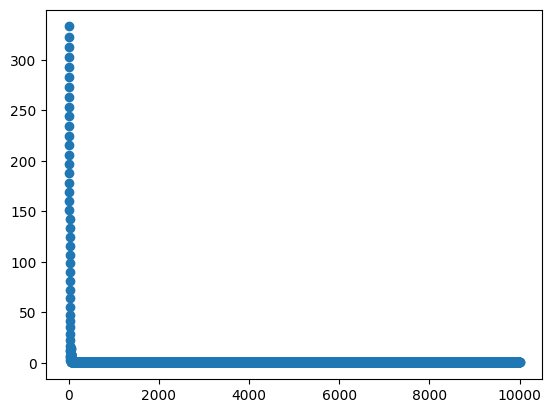

In [255]:
import matplotlib.pyplot as plt

plt.plot(range(epochs), losses.detach(), 'o')

In [256]:
print(f"Final Loss:", losses[-1].detach().numpy())

Final Loss: 0.31573266


## Evaluate

In [257]:
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_class = (y_pred > 0.5).float()

    accuracy = (y_pred_class == y_test).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.8645598292350769
